In [1]:
%config SqlMagic.autopandas = True
%config SqlMagic.feedback = False
%config SqlMagic.displaycon = False 

In [2]:
import duckdb
import altair as alt
from IPython.display import Image, display

alt.renderers.enable('default')
alt.data_transformers.enable('default')

%load_ext sql
conn = duckdb.connect()
%sql conn --alias duckdb

The 'toml' package isn't installed. To load settings from pyproject.toml or ~/.jupysql/config, install with: pip install toml

In [3]:
%%sql
INSTALL ducklake;
LOAD ducklake;
ATTACH 'ducklake:metadata.ducklake' AS scisciDB (DATA_PATH '/gpfs1/home/j/s/jstonge1/scisciDB');
USE scisciDB;

,Success


In [20]:
%sql select * from scisciDB.pro_geogr order by publication_year desc limit 5;

,id,doi,title,display_name,publication_year,publication_date,created_date,updated_date,language,type,...,topics,keywords,mesh,grants,sustainable_development_goals,locations,primary_location,best_oa_location,open_access,abstract_inverted_index
0,https://openalex.org/W7085713869,https://doi.org/10.1080/00330124.2025.2539213,Interpreting Adolescent Experience: Methodolog...,Interpreting Adolescent Experience: Methodolog...,2025,2025-08-14,2025-10-10,2025-11-06,en,article,...,"[{'id': 'https://openalex.org/T13015', 'displa...","[{'keyword': None, 'score': 0.4532051}, {'keyw...",[],[],[],"[{'is_oa': False, 'landing_page_url': 'https:/...","{'id': None, 'display_name': None, 'landing_pa...",<NA>,"{'is_oa': False, 'oa_status': 'closed', 'oa_ur...",None
1,https://openalex.org/W4406165305,https://doi.org/10.1080/00330124.2025.2435232,Manuscript Reviewers,Manuscript Reviewers,2025,2025-01-02,2025-10-10,2025-11-06,en,article,...,[],"[{'keyword': None, 'score': 0.35936946}]",[],[],[],"[{'is_oa': False, 'landing_page_url': 'https:/...","{'id': None, 'display_name': None, 'landing_pa...",<NA>,"{'is_oa': False, 'oa_status': 'closed', 'oa_ur...",None
2,https://openalex.org/W4415596645,https://doi.org/10.1080/00330124.2025.2565472,Energy and Colonialism: How Energy Policy Is D...,Energy and Colonialism: How Energy Policy Is D...,2025,2025-10-27,2025-10-28,2025-11-06,en,article,...,"[{'id': 'https://openalex.org/T11862', 'displa...",[],[],[],[],"[{'is_oa': False, 'landing_page_url': 'https:/...","{'id': None, 'display_name': None, 'landing_pa...",<NA>,"{'is_oa': False, 'oa_status': 'closed', 'oa_ur...",None
3,https://openalex.org/W4408568717,https://doi.org/10.1080/00330124.2025.2468680,Behavioral Mapping and Rhythmanalysis: Spatial...,Behavioral Mapping and Rhythmanalysis: Spatial...,2025,2025-03-18,2025-10-10,2025-11-06,en,article,...,"[{'id': 'https://openalex.org/T14101', 'displa...","[{'keyword': None, 'score': 0.82064664}, {'key...",[],[],"[{'id': 'https://metadata.un.org/sdg/11', 'dis...","[{'is_oa': False, 'landing_page_url': 'https:/...","{'id': None, 'display_name': None, 'landing_pa...",<NA>,"{'is_oa': False, 'oa_status': 'closed', 'oa_ur...",None
4,https://openalex.org/W4409165175,https://doi.org/10.1080/00330124.2025.2478080,Listening to Silent Geographies of Indigenous ...,Listening to Silent Geographies of Indigenous ...,2025,2025-04-02,2025-10-10,2025-11-06,en,article,...,"[{'id': 'https://openalex.org/T10348', 'displa...","[{'keyword': None, 'score': 0.8544719}, {'keyw...",[],[],"[{'id': 'https://metadata.un.org/sdg/10', 'dis...","[{'is_oa': False, 'landing_page_url': 'https:/...","{'id': None, 'display_name': None, 'landing_pa...",<NA>,"{'is_oa': False, 'oa_status': 'closed', 'oa_ur...",None


#### topic structure

In [25]:
%sql select doi, title, topics from scisciDB.pro_geogr where id = 'https://openalex.org/W4409165175'

,doi,title,topics
0,https://doi.org/10.1080/00330124.2025.2478080,Listening to Silent Geographies of Indigenous ...,"[{'id': 'https://openalex.org/T10348', 'displa..."


One paper can have multiple topics

In [26]:
%sql select UNNEST(topics, recursive := true) from scisciDB.pro_geogr where id = 'https://openalex.org/W4409165175';

,id,display_name,id_1,display_name_1,id_2,display_name_2,id_3,display_name_3
0,https://openalex.org/T10348,"Indigenous Health, Education, and Rights",https://openalex.org/subfields/3306,Health,https://openalex.org/fields/33,Social Sciences,https://openalex.org/domains/2,Social Sciences
1,https://openalex.org/T12614,Indigenous Studies and Ecology,https://openalex.org/subfields/3600,General Health Professions,https://openalex.org/fields/36,Health Professions,https://openalex.org/domains/4,Health Sciences
2,https://openalex.org/T11933,Mining and Resource Management,https://openalex.org/subfields/2215,Building and Construction,https://openalex.org/fields/22,Engineering,https://openalex.org/domains/3,Physical Sciences


In [ ]:
%%sql
# Assuming first topic in the list is the primary topic, like on the API
count_df << 
SELECT publication_year, 
  topics[1].display_name AS topic_name,
  topics[1].subfield.display_name AS subfield_name,
  topics[1].field.display_name AS field_name,
  topics[1].domain.display_name AS domain_name,
  COUNT(*) as num_papers
FROM scisciDB.pro_geogr
GROUP BY publication_year, topic_name, subfield_name, field_name, domain_name
ORDER BY publication_year, num_papers DESC;

In [78]:
count_df.head()

,publication_year,topic_name,subfield_name,field_name,domain_name,num_papers
0,1949,NaN,NaN,NaN,NaN,18
1,1949,Historical Geography and Geographical Thought,"Geography, Planning and Development",Social Sciences,Social Sciences,10
2,1949,Geographic Information Systems Studies,"Geography, Planning and Development",Social Sciences,Social Sciences,5
3,1949,Geography Education and Pedagogy,"Geography, Planning and Development",Social Sciences,Social Sciences,2
4,1949,Rangeland and Wildlife Management,Ecology,Environmental Science,Physical Sciences,1


In [92]:
count_df[count_df.topic_name.isna()].num_papers.sum()

np.int64(1424)

In [96]:
nans_pap = count_df[count_df.topic_name.isna()].num_papers.sum() 
tot_pap = count_df.num_papers.sum()
pct_nans = nans_pap / tot_pap * 100
print(f"{round(pct_nans, 2)}% papers don't have topics")
print(f"or {nans_pap} papers out of {tot_pap}")

23.75% papers don't have topics
or 1424 papers out of 5997


#### Subfield trends over time

We take the top 10 subfields by total paper count and show two stacked bar charts side by side: one with raw counts (to see overall growth) and one normalized to proportions (to see how the subfield mix shifts over time). Years are binned into 2-year intervals.


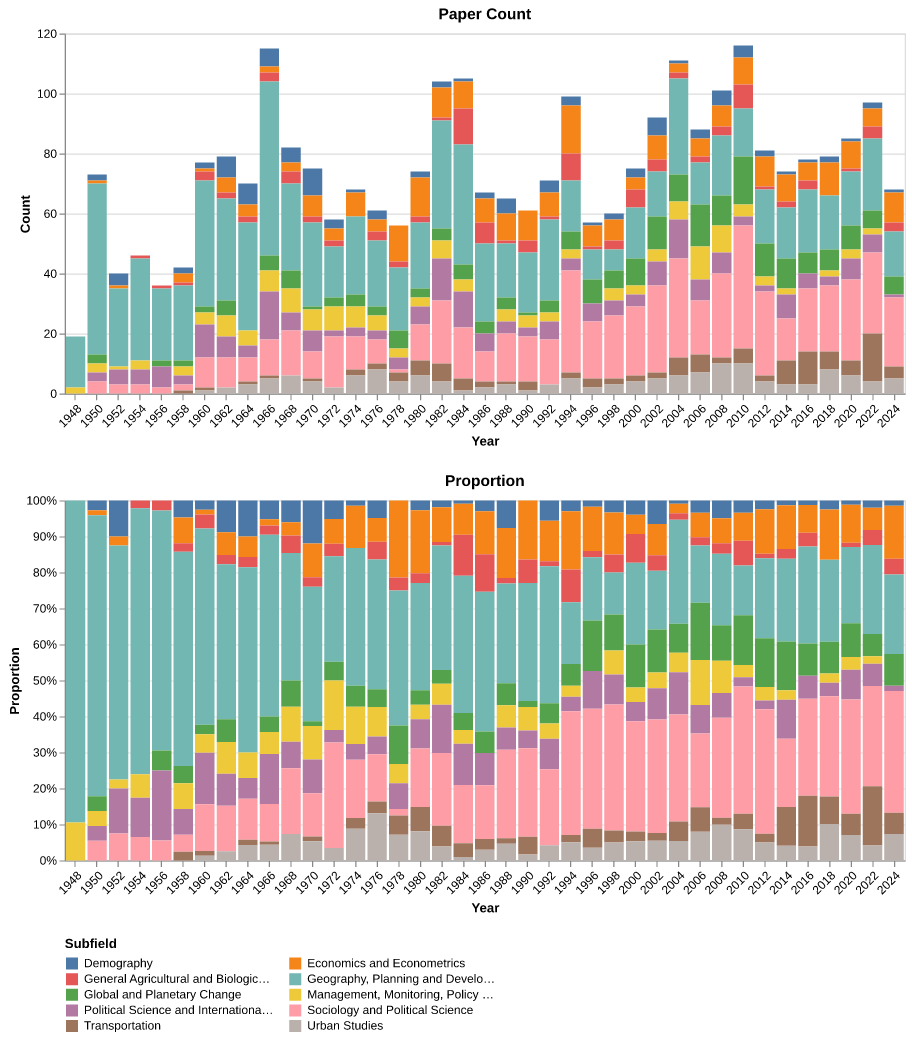

In [73]:
TOP_N = 10

top_subfields = (
    count_df.dropna(subset=['subfield_name'])
    .groupby('subfield_name')['num_papers']
    .sum()
    .nlargest(TOP_N)
    .index.tolist()
)

top_df_subfield = count_df[count_df['subfield_name'].isin(top_subfields)].copy()
top_df_subfield['year_bin'] = (top_df_subfield['publication_year'] // 2) * 2
top_df_subfield = top_df_subfield.groupby(['year_bin', 'subfield_name'])['num_papers'].sum().reset_index()

base = alt.Chart(top_df_subfield).encode(
    x=alt.X('year_bin:O', title='Year', axis=alt.Axis(labelAngle=-45)),
    color=alt.Color('subfield_name:N', title='Subfield',
                    legend=alt.Legend(orient='bottom', columns=2)),
    tooltip=['year_bin:O', 'subfield_name:N', 'num_papers:Q']
)

counts = base.mark_bar().encode(
    y=alt.Y('num_papers:Q', title='Count')
).properties(width=700, height=300, title='Paper Count')

normalized = base.mark_bar().encode(
    y=alt.Y('num_papers:Q', title='Proportion', stack='normalize')
).properties(width=700, height=300, title='Proportion')

(counts & normalized).resolve_scale(
    color='shared'
).save('chart.png', scale_factor=1.2)

Image('chart.png')

#### Topic trends over time

We take the top 10 topic by total paper count and show two stacked bar charts side by side: one with raw counts (to see overall growth) and one normalized to proportions (to see how the subfield mix shifts over time). Years are binned into 2-year intervals.


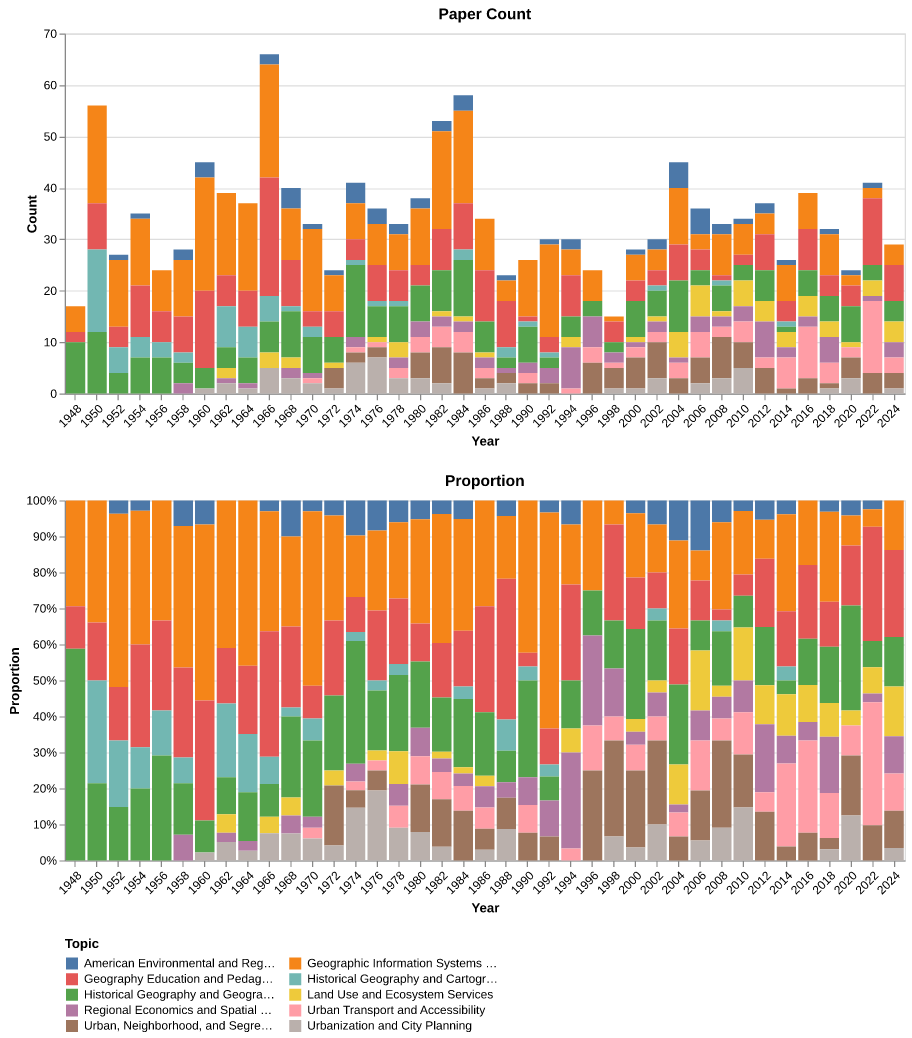

In [76]:
TOP_N = 10

top_topics = (
    count_df.dropna(subset=['topic_name'])
    .groupby('topic_name')['num_papers']
    .sum()
    .nlargest(TOP_N)
    .index.tolist()
)

top_df = count_df[count_df['topic_name'].isin(top_topics)].copy()
top_df['year_bin'] = (top_df['publication_year'] // 2) * 2
top_df = top_df.groupby(['year_bin', 'topic_name'])['num_papers'].sum().reset_index()

base = alt.Chart(top_df).encode(
    x=alt.X('year_bin:O', title='Year', axis=alt.Axis(labelAngle=-45)),
    color=alt.Color('topic_name:N', title='Topic',
                    legend=alt.Legend(orient='bottom', columns=2)),
    tooltip=['year_bin:O', 'topic_name:N', 'num_papers:Q']
)

counts = base.mark_bar().encode(
    y=alt.Y('num_papers:Q', title='Count')
).properties(width=700, height=300, title='Paper Count')

normalized = base.mark_bar().encode(
    y=alt.Y('num_papers:Q', title='Proportion', stack='normalize')
).properties(width=700, height=300, title='Proportion')

(counts & normalized).resolve_scale(
    color='shared'
).save('chart.png', scale_factor=1.2)

Image('chart.png')

Lets look at the same info as heatmap, easier to see

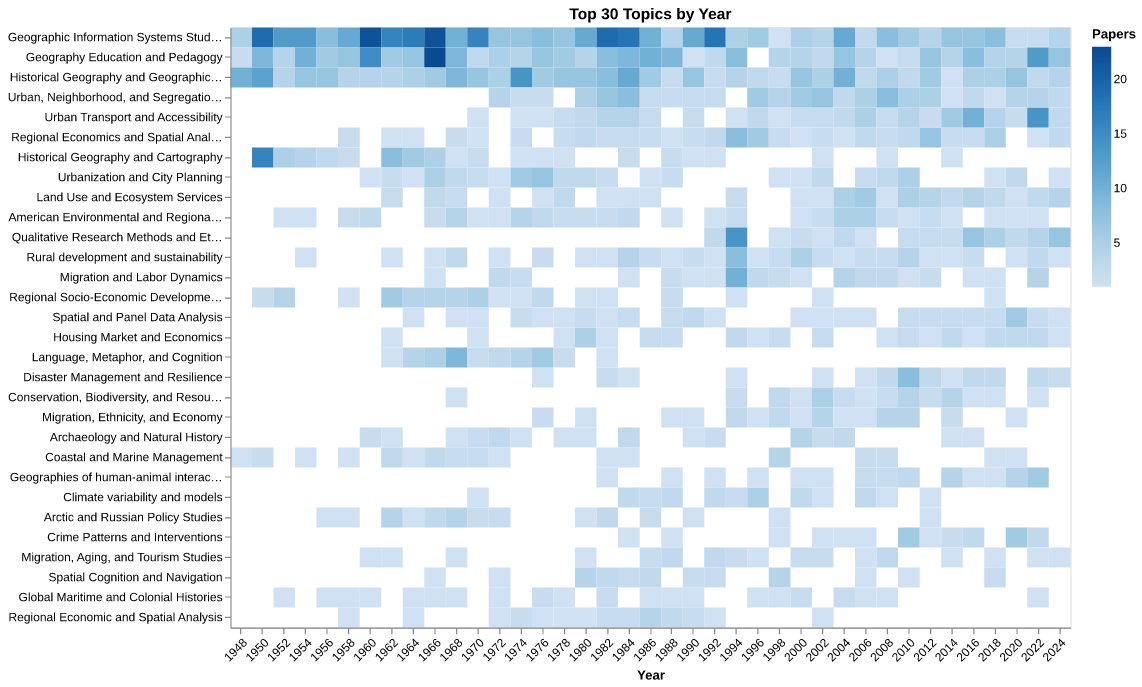

In [97]:
TOP_N = 30

top_topics = (
    count_df.dropna(subset=['topic_name'])
    .groupby('topic_name')['num_papers']
    .sum()
    .nlargest(TOP_N)
    .index.tolist()
)

top_df = count_df[count_df['topic_name'].isin(top_topics)].copy()
top_df['year_bin'] = (top_df['publication_year'] // 2) * 2
top_df = top_df.groupby(['year_bin', 'topic_name'])['num_papers'].sum().reset_index()

alt.Chart(top_df).mark_rect().encode(
    x=alt.X('year_bin:O', title='Year', axis=alt.Axis(labelAngle=-45)),
    y=alt.Y('topic_name:N', title=None, sort=top_topics),
    color=alt.Color('num_papers:Q', scale=alt.Scale(scheme='blues'), title='Papers'),
    tooltip=['year_bin:O', 'topic_name:N', 'num_papers:Q']
).properties(
    width=700,
    height=500,
    title=f'Top {TOP_N} Topics by Year'
).save('chart_top_topics.png', scale_factor=1.2)

Image('chart_top_topics.png')